<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2.2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Alle in diesem Dokument geschriebenen Zeilen Code sind von mir eigenständig geschrieben. Für ein sauberes und struktiriertes Dokument wurde eine eigene Pythonlibary geschrieben, welche insbesondere ans PAP angepasst wurde. Dieses ist unter dem Namen "Papulator" auf meinem GitHub zu finden. Diese soll setig ausgearbeitet werden. Der Stand dieses Protokolls ist der 19.05.2026.
 
----

# Inhaltsverzeichnis zur Auswertung
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Auswertung der Aufgaben](#Auswertung-der-Aufgaben)
    * [Aufgabe 1](#Aufgabe-1)
    * [Aufgabe 2](#Aufgabe-2)
    * [Aufgabe 3](#Aufgabe-3)
    * [Aufgabe 4](#Aufgabe-4)
    * [Aufgabe 5](#Aufgabe-5)
    * [Aufgabe 6](#Aufgabe-6)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [1]:
versuchsnummer = "243"
versuchsname = "White_Noise" 
aufgabe = "0z"
plt_save_folder = f"../img/plots/"

# Import aller genutzen Libaries

In [2]:
# Eigene Pythonlibary für das Pap
import Papulator as pap
from Papulator import Colors as c
from Papulator import Sympy_Symbols as sym

# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

import astropy.units as u

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd
import csv
import re

from io import StringIO

# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

<hr>
<hr>

# Auswertung der Aufgaben

<hr>

## Aufgabe 1

Plot saved to ../img/plots/Frequenzgang_1a.pdf
Plot saved to ../img/plots/Frequenzgang_30K.pdf


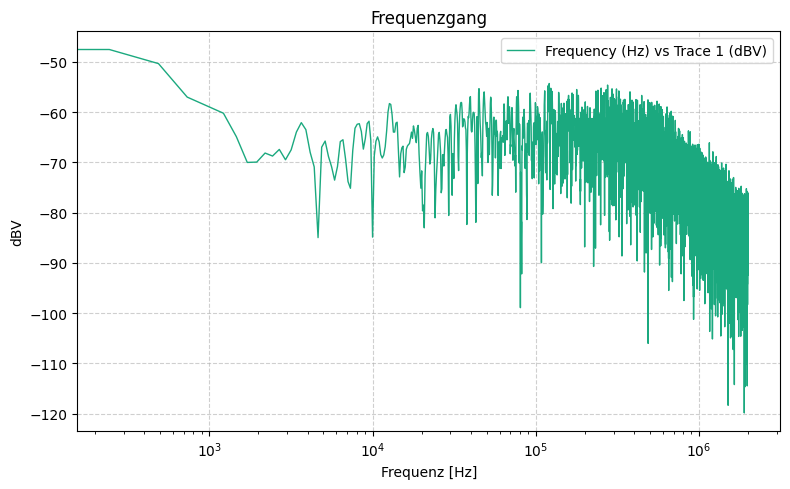

In [3]:
aufgabe = '1a'
pap.plot_general_csv("A1/5KOhm_FFT.csv", "Time (s)", "Channel 1 (V)", 
                 title="Frequenzgang", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf", show_plot=False)

aufgabe = '30K'
pap.plot_general_csv("A1/Spectrum_30k.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title="Frequenzgang", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

Plot saved to ../img/plots/Frequenzgang_5K.pdf


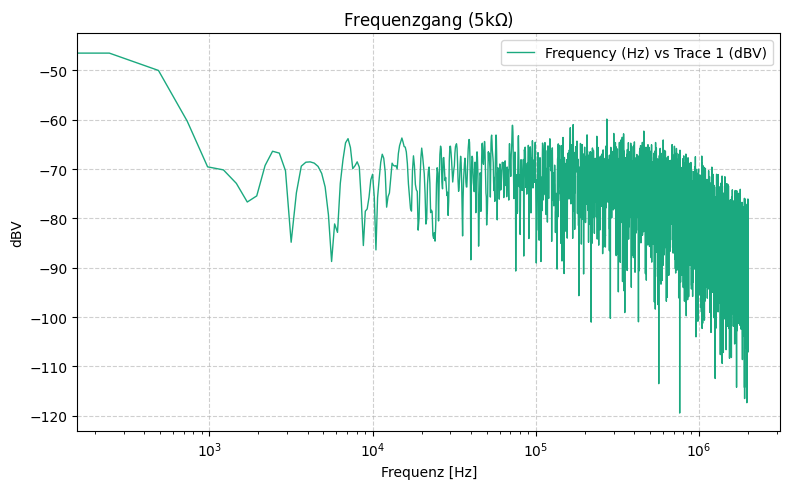

In [4]:
aufgabe = '5K'
pap.plot_general_csv("A1/Spectrum_5k.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title=fr"Frequenzgang (5k$\Omega$)", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

Plot saved to ../img/plots/Frequenzgang_Bandfliter-5K.pdf


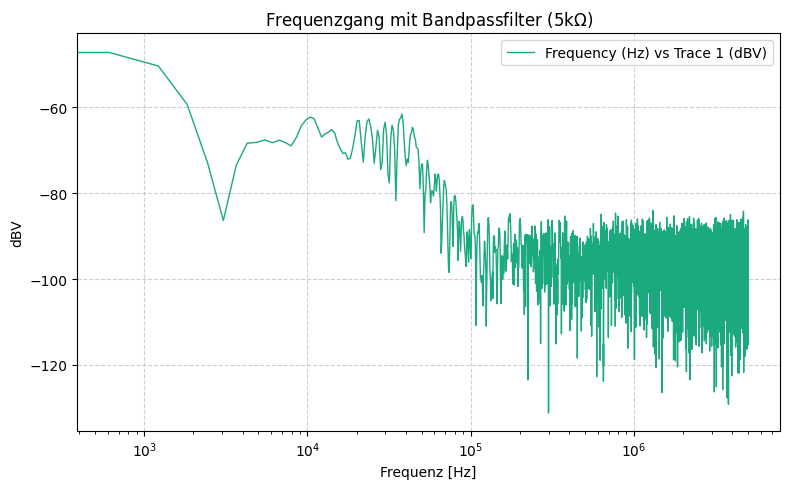

In [5]:
aufgabe = 'Bandfliter-5K'
pap.plot_general_csv("A1/Spectrum_5k_MitDASBandpassfilter.csv", "Frequency (Hz)", "Trace 1 (dBV)", 
                 title=fr"Frequenzgang mit Bandpassfilter (5k$\Omega$)", xlabel="Frequenz [Hz]", ylabel="dBV", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

<hr>

## Aufgabe 2

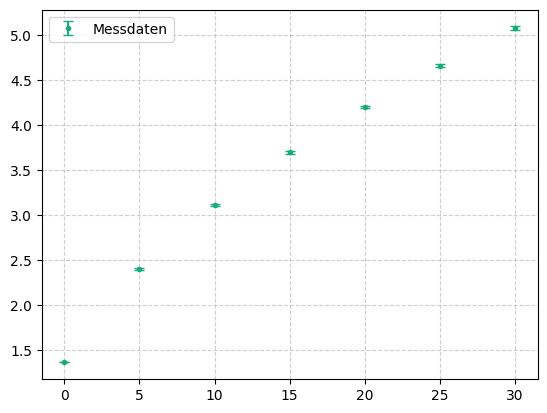

<Axes: >

In [17]:
n_messungen = 127
wid_stands = np.array([0, 5, 10, 15, 20, 25, 30])
avg_Vr = np.array([1.3702, 2.4042, 3.1159, 3.6989, 4.201, 4.6594, 5.0751])
sig_Vr = np.array([0.0054, 0.0093, 0.011, 0.0149, 0.0147, 0.0173, 0.0188])
err_Vr = sig_Vr/np.sqrt(n_messungen)

plt.errorbar(wid_stands, avg_Vr, sig_Vr, label=fr'Messdaten', fmt='.', capsize=3.5)
pap.plot_me()

Plot saved to ../img/plots/Frequenzgang_2a.pdf


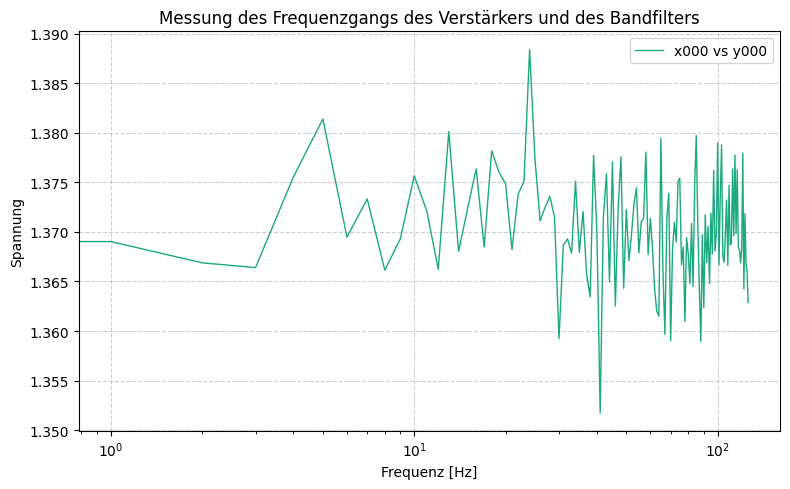

In [ ]:
aufgabe = '2a'
pap.plot_general_csv("A2/0k.csv", "x000", "y000", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

Plot saved to ../img/plots/Frequenzgang_2b.pdf


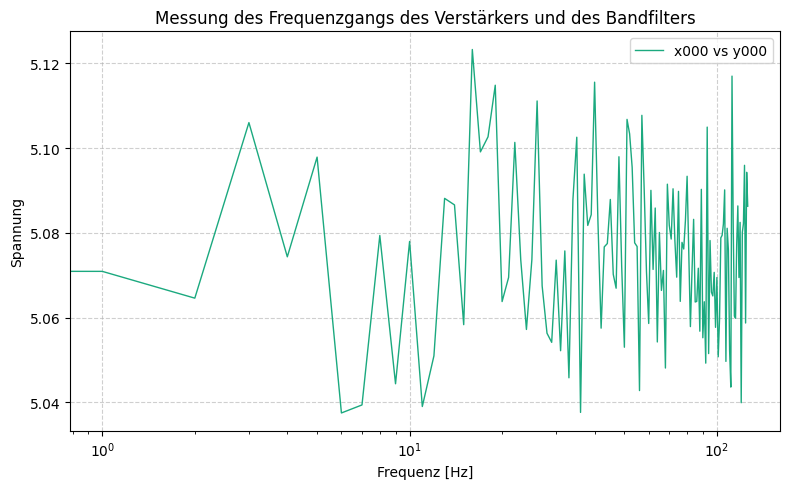

In [10]:
aufgabe = '2b'
pap.plot_general_csv("A2/30k.csv", "x000", "y000", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

In [ ]:
df = pd.read_csv("A2/30k.csv", comment='#', engine='python')
x_0 = df['x0000']

     x0000     y0000
0      0.0  5.102677
1      1.0  5.070908
2      2.0  5.064589
3      3.0  5.106000
4      4.0  5.074339
..     ...       ...
122  122.0  5.082135
123  123.0  5.095924
124  124.0  5.058726
125  125.0  5.094274
126  126.0  5.086282

[127 rows x 2 columns]


<hr>

## Aufgabe 3

Plot saved to ../img/plots/Frequenzgang_3a.pdf


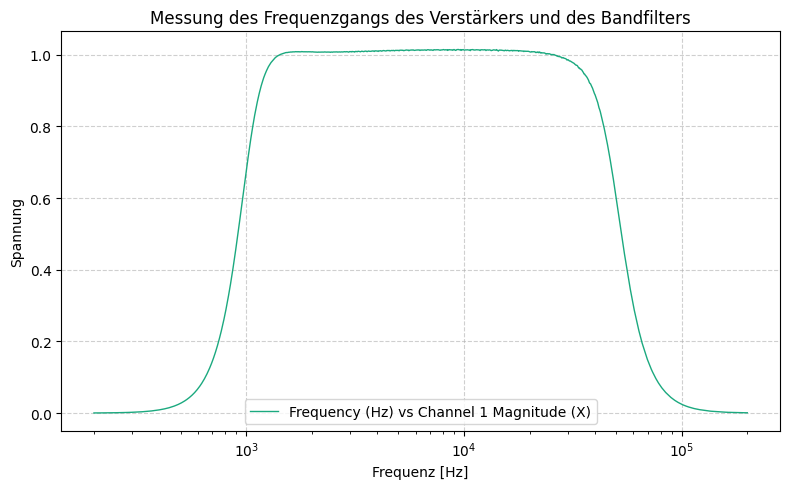

In [8]:
aufgabe = '3a'
pap.plot_general_csv("A3/Frequenzgang.csv", "Frequency (Hz)", "Channel 1 Magnitude (X)", 
                 title=fr"Messung des Frequenzgangs des Verstärkers und des Bandfilters", xlabel="Frequenz [Hz]", ylabel="Spannung", 
                 log_x=True, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")

<hr>

## Aufgabe 4

Plot saved to ../img/plots/Frequenzgang_4a.pdf


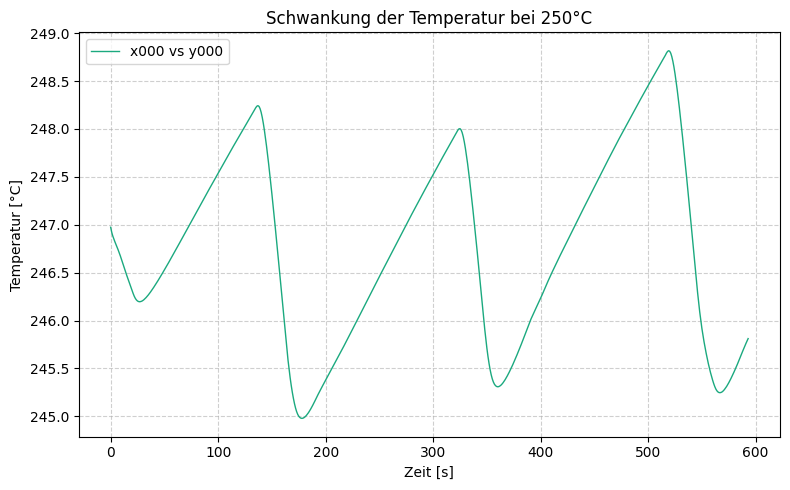

In [9]:
aufgabe = '4a'
pap.plot_general_csv("A4/Schwankung_der_Temperatur_250C.csv", "x000", "y000", 
                 title=fr"Schwankung der Temperatur bei 250°C", xlabel="Zeit [s]", ylabel="Temperatur [°C]", 
                 log_x=False, save_path=fr"{plt_save_folder}Frequenzgang_{aufgabe}.pdf")